# NB08: Interaction Modeling — Synergy, Antagonism, and Formulation Impact

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Detect and classify pairwise interactions between consortium members and assess how they affect formulation design.

## Data Sources
1. **`fact_competition_assay`** — 720 pairwise (A+B) tests + 720 single-commensal tests against 6 reporters. Directly measures whether pairs synergize or antagonize in pathogen inhibition.
2. **`fact_pairwise_interaction`** vs **`fact_carbon_utilization`** — Same 430 isolates on 21 carbon sources, but under co-culture vs monoculture conditions. Reveals metabolic facilitation/competition per substrate.

## Interaction Classes
- **Synergistic inhibition**: Pair inhibits PA more than either member alone
- **Additive**: Pair effect ≈ sum (or max) of individual effects
- **Antagonistic**: Pair inhibits less than expected — members interfere with each other
- **Metabolic facilitation**: One organism's byproducts enable another's growth
- **Metabolic competition**: Co-culture reduces growth vs monoculture (resource depletion)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

GOLD = Path.home() / 'protect' / 'gold'
DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

comp = pd.read_parquet(GOLD / 'fact_competition_assay.snappy.parquet')
cu = pd.read_parquet(GOLD / 'fact_carbon_utilization.snappy.parquet')
pw = pd.read_parquet(GOLD / 'fact_pairwise_interaction.snappy.parquet')
ctrl = pd.read_parquet(GOLD / 'fact_inhibition_control.snappy.parquet')
isolates = pd.read_parquet(GOLD / 'dim_isolate.snappy.parquet')

print(f'Competition assay: {len(comp)} rows')
print(f'Carbon utilization: {len(cu)} rows')
print(f'Pairwise interaction: {len(pw)} rows')
print(f'Inhibition control: {len(ctrl)} rows')

Competition assay: 1584 rows
Carbon utilization: 826 rows
Pairwise interaction: 826 rows
Inhibition control: 826 rows


## 1. Competition Assay: Pairwise Inhibition of PA14

The assay tests commensals alone (A only) and in pairs (A+B) against PA14. If pair RFU < individual RFU, the pair is synergistic (more inhibition). RFU is reporter fluorescence — lower = more inhibition.

In [2]:
comp['raw_rfu'] = pd.to_numeric(comp['raw_rfu'], errors='coerce')

# Separate controls, singles, and pairs
controls = comp[(comp.asma_a_id == 'n/a') & (comp.asma_b_id == 'n/a')].copy()
singles = comp[(comp.asma_a_id != 'n/a') & (comp.asma_b_id == 'n/a')].copy()
pairs = comp[(comp.asma_a_id != 'n/a') & (comp.asma_b_id != 'n/a')].copy()

print(f'Controls (PA alone): {len(controls)} measurements')
print(f'Singles (one commensal): {len(singles)} measurements')
print(f'Pairs (two commensals): {len(pairs)} measurements')

# Which isolates?
print(f'\nA isolates: {sorted(singles.asma_a_id.unique())}')
print(f'B isolates in pairs: {sorted(pairs.asma_b_id.unique())}')
print(f'Reporters: {sorted(comp.reporter.unique())}')

# Map to species
all_ids = set(singles.asma_a_id.unique()) | set(pairs.asma_b_id.unique())
id_species = isolates[isolates.asma_id.isin(all_ids)].drop_duplicates('asma_id').set_index('asma_id')['species']
print(f'\nSpecies:')
for aid in sorted(all_ids):
    print(f'  {aid}: {id_species.get(aid, "Unknown")}')

Controls (PA alone): 144 measurements
Singles (one commensal): 720 measurements
Pairs (two commensals): 720 measurements

A isolates: ['ASMA-1478', 'ASMA-2260', 'ASMA-2464', 'ASMA-3643', 'ASMA-3913', 'ASMA-3914', 'ASMA-3915', 'ASMA-3916', 'ASMA-3917', 'ASMA-3918', 'ASMA-3919', 'ASMA-3920', 'ASMA-3921', 'ASMA-3922', 'ASMA-3923', 'ASMA-3924', 'ASMA-3925', 'ASMA-3926', 'ASMA-3927', 'ASMA-3928', 'ASMA-3929', 'ASMA-3930', 'ASMA-3931', 'ASMA-3932', 'ASMA-3933', 'ASMA-3934', 'ASMA-3935', 'ASMA-3936']
B isolates in pairs: ['ASMA-1197', 'ASMA-2260', 'ASMA-2464']
Reporters: ['AB_Reporter', 'ASMA-137_Reporter', 'ASMA-143_Reporter', 'KP_Reporter', 'PA14_FA_Reporter', 'PA14_KEH108_Reporter']

Species:
  ASMA-1197: Rothia sp001808955
  ASMA-1478: Streptococcus salivarius_D
  ASMA-2260: asma_id
ASMA-2260    Bacillus licheniformis
ASMA-2260    Bacillus licheniformis
Name: species, dtype: str
  ASMA-2464: Staphylococcus epidermidis
  ASMA-3643: Neisseria mucosa
  ASMA-3913: Neisseria sp001809325
  ASMA

In [3]:
# Focus on PA14 reporter
pa_controls = controls[controls.reporter == 'PA14_KEH108_Reporter']
pa_singles = singles[singles.reporter == 'PA14_KEH108_Reporter']
pa_pairs = pairs[pairs.reporter == 'PA14_KEH108_Reporter']

# Compute inhibition as % reduction from control RFU
# Group by inoculation OD for fair comparison
control_mean_rfu = pa_controls.groupby('reporter_inoculation_od')['raw_rfu'].mean()
print('PA14 control RFU by starting OD:')
print(control_mean_rfu.to_string())

def compute_inhibition(row, control_means):
    od = row['reporter_inoculation_od']
    ctrl_rfu = control_means.get(od, np.nan)
    if pd.isna(ctrl_rfu) or ctrl_rfu == 0:
        return np.nan
    return (1 - row['raw_rfu'] / ctrl_rfu) * 100

pa_singles['pct_inhibition'] = pa_singles.apply(compute_inhibition, axis=1, control_means=control_mean_rfu)
pa_pairs['pct_inhibition'] = pa_pairs.apply(compute_inhibition, axis=1, control_means=control_mean_rfu)

print(f'\nSingle commensal inhibition: mean={pa_singles.pct_inhibition.mean():.1f}%, median={pa_singles.pct_inhibition.median():.1f}%')
print(f'Pair inhibition: mean={pa_pairs.pct_inhibition.mean():.1f}%, median={pa_pairs.pct_inhibition.median():.1f}%')

PA14 control RFU by starting OD:
reporter_inoculation_od
0.0001    168.283333
0.001     189.316667

Single commensal inhibition: mean=31.1%, median=30.3%
Pair inhibition: mean=33.5%, median=34.0%


In [4]:
# Synergy analysis: for each pair, compare to the better single member
# Expected (additive): max(inh_A, inh_B) or mean(inh_A, inh_B)
# Synergistic: pair > max(A, B)
# Antagonistic: pair < max(A, B)

# Average inhibition per A isolate (across OD/plate replicates)
single_mean = pa_singles.groupby(['asma_a_id', 'reporter_inoculation_od'])['pct_inhibition'].mean().reset_index()
single_mean.columns = ['isolate', 'od', 'single_inh']

# Average inhibition per pair (A+B)
pair_mean = pa_pairs.groupby(['asma_a_id', 'asma_b_id', 'reporter_inoculation_od'])['pct_inhibition'].mean().reset_index()
pair_mean.columns = ['isolate_a', 'isolate_b', 'od', 'pair_inh']

# Merge to get expected values
pair_analysis = pair_mean.merge(
    single_mean.rename(columns={'isolate': 'isolate_a', 'single_inh': 'inh_a'}),
    on=['isolate_a', 'od']
)
# B isolates may also have single data (if they're in the A set too)
pair_analysis = pair_analysis.merge(
    single_mean.rename(columns={'isolate': 'isolate_b', 'single_inh': 'inh_b'}),
    on=['isolate_b', 'od'], how='left'
)

# Compute expected and synergy
pair_analysis['expected_max'] = pair_analysis[['inh_a', 'inh_b']].max(axis=1)
pair_analysis['expected_mean'] = pair_analysis[['inh_a', 'inh_b']].mean(axis=1)
pair_analysis['synergy_vs_max'] = pair_analysis['pair_inh'] - pair_analysis['expected_max']
pair_analysis['synergy_vs_mean'] = pair_analysis['pair_inh'] - pair_analysis['expected_mean']

# Classify
pair_analysis['interaction_class'] = pd.cut(
    pair_analysis['synergy_vs_max'],
    bins=[-np.inf, -10, 10, np.inf],
    labels=['Antagonistic', 'Additive', 'Synergistic']
)

print('Interaction classification (vs max single):')
print(pair_analysis.interaction_class.value_counts().to_string())
print(f'\nMean synergy score: {pair_analysis.synergy_vs_max.mean():.1f}%')
print(f'\nPer-pair results:')
pair_summary = pair_analysis.groupby(['isolate_a', 'isolate_b']).agg(
    mean_pair_inh=('pair_inh', 'mean'),
    mean_inh_a=('inh_a', 'mean'),
    mean_inh_b=('inh_b', 'mean'),
    mean_synergy=('synergy_vs_max', 'mean')
).round(1)
# Add species names
for col in ['isolate_a', 'isolate_b']:
    pair_summary[f'{col}_species'] = [id_species.get(idx, '?') for idx in pair_summary.index.get_level_values(col)]
print(pair_summary.to_string())

Interaction classification (vs max single):
interaction_class
Additive        4
Antagonistic    3
Synergistic     1

Mean synergy score: -5.8%

Per-pair results:
                     mean_pair_inh  mean_inh_a  mean_inh_b  mean_synergy           isolate_a_species                                                                                          isolate_b_species
isolate_a isolate_b                                                                                                                                                                                            
ASMA-1478 ASMA-1197           -3.2        16.7         NaN         -19.8  Streptococcus salivarius_D                                                                                         Rothia sp001808955
ASMA-3643 ASMA-2260           47.1        41.8        33.3           5.3            Neisseria mucosa  asma_id
ASMA-2260    Bacillus licheniformis
ASMA-2260    Bacillus licheniformis
Name: species, dtype: str
      

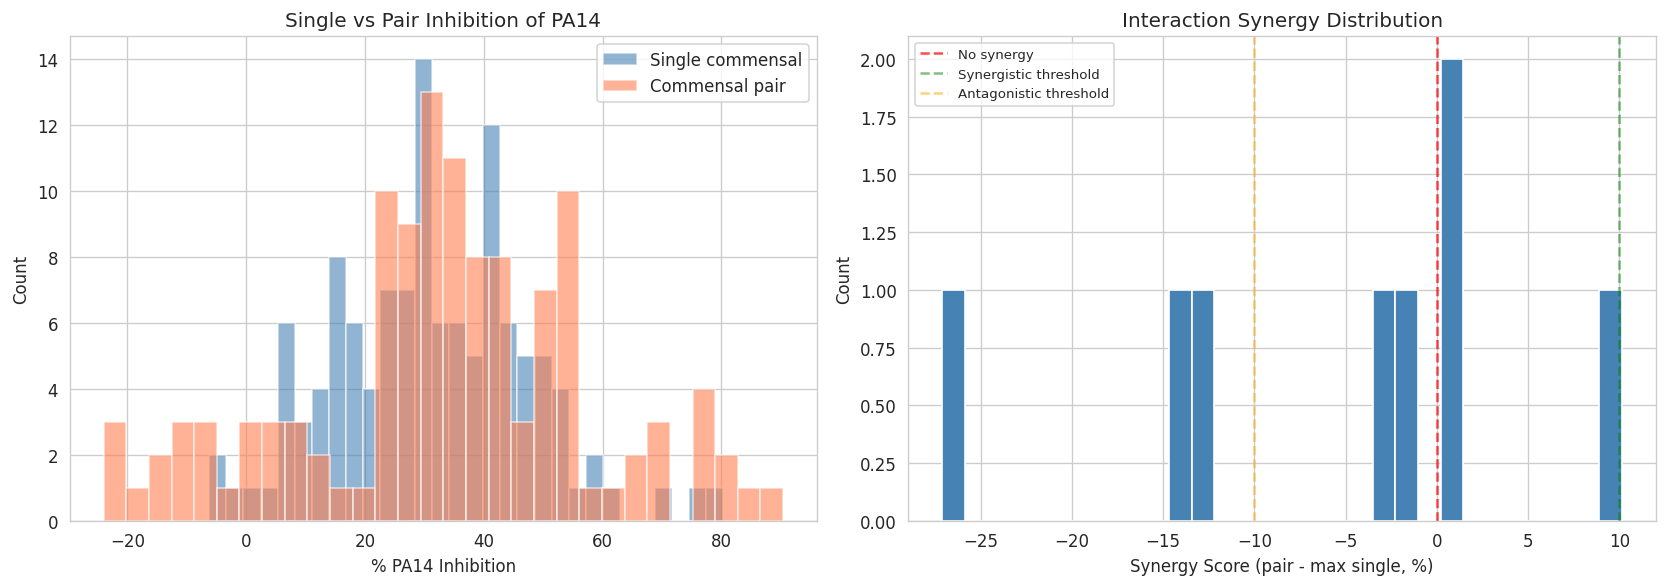

In [5]:
# Visualization: pairs vs singles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribution of pair vs single inhibition
ax = axes[0]
ax.hist(pa_singles.pct_inhibition.dropna(), bins=30, alpha=0.6, label='Single commensal', color='steelblue')
ax.hist(pa_pairs.pct_inhibition.dropna(), bins=30, alpha=0.6, label='Commensal pair', color='coral')
ax.set_xlabel('% PA14 Inhibition')
ax.set_ylabel('Count')
ax.set_title('Single vs Pair Inhibition of PA14')
ax.legend()

# (b) Synergy score distribution
ax = axes[1]
pair_analysis.synergy_vs_max.hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', ls='--', alpha=0.7, label='No synergy')
ax.axvline(10, color='green', ls='--', alpha=0.5, label='Synergistic threshold')
ax.axvline(-10, color='orange', ls='--', alpha=0.5, label='Antagonistic threshold')
ax.set_xlabel('Synergy Score (pair - max single, %)')
ax.set_ylabel('Count')
ax.set_title('Interaction Synergy Distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / '08_pair_vs_single_inhibition.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Carbon Source Interaction: Monoculture vs Co-Culture

Compare `fact_carbon_utilization` (monoculture) with `fact_pairwise_interaction` (co-culture). If the tables differ, this reveals per-substrate facilitation or competition.

In [6]:
carbon_sources = ['glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

# Convert to numeric
for df in [cu, pw, ctrl]:
    for col in carbon_sources:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Check: are CU and PW actually different?
# Match by sample_id and asma_id
merged = cu.merge(pw, on=['sample_id', 'asma_id'], suffixes=('_mono', '_co'))
print(f'Matched rows (CU vs PW): {len(merged)}')

# Compute difference per substrate
diffs = {}
for cs in carbon_sources:
    mono = merged[f'{cs}_mono']
    co = merged[f'{cs}_co']
    diff = (co - mono).mean()
    corr = mono.corr(co)
    diffs[cs] = {'mean_diff': diff, 'correlation': corr, 'identical': np.allclose(mono.dropna(), co.dropna(), atol=1e-6)}

diff_df = pd.DataFrame(diffs).T
print(f'\nMonoculture vs Co-culture per substrate:')
print(diff_df.round(4).to_string())

if diff_df['identical'].all():
    print('\n*** NOTE: CU and PW tables appear identical. ***')
    print('The pairwise interaction data may use a different experimental design')
    print('not captured in these endpoint OD tables.')
else:
    # Real interaction effects
    print(f'\nSubstrates with facilitation (co > mono): {(diff_df.mean_diff > 0.02).sum()}')
    print(f'Substrates with competition (co < mono): {(diff_df.mean_diff < -0.02).sum()}')

Matched rows (CU vs PW): 826

Monoculture vs Co-culture per substrate:
              mean_diff correlation identical
glucose             0.0         1.0      True
lactate             0.0         1.0      True
serine              0.0         1.0      True
threonine           0.0         1.0      True
alanine             0.0         1.0      True
glycine             0.0         1.0      True
proline             0.0         1.0      True
isoleucine          0.0         1.0      True
leucine             0.0         1.0      True
valine              0.0         1.0      True
aspartate           0.0         1.0      True
glutamate           0.0         1.0      True
phenylalanine       0.0         1.0      True
tryptophan          0.0         1.0      True
lysine              0.0         1.0      True
histidine           0.0         1.0      True
arginine            0.0         1.0      True
ornithine           0.0         1.0      True
cystein             0.0         1.0      True
methionin

## 3. Dose-Response Interaction Patterns

The competition assay varies inoculation OD for both A and B. This reveals whether interactions are dose-dependent.

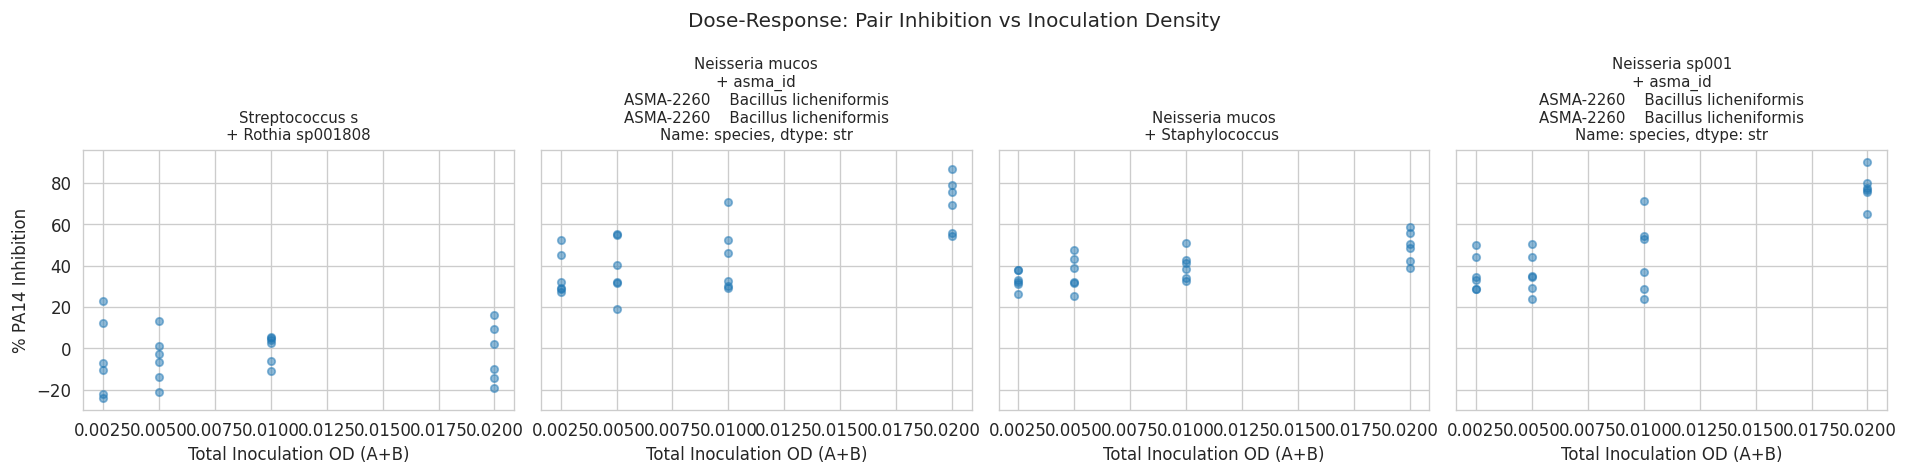

In [7]:
# Dose-response: how does pair inhibition change with inoculation density?
pa_pairs['a_od'] = pd.to_numeric(pa_pairs['asma_a_inoculation_od'], errors='coerce')
pa_pairs['b_od'] = pd.to_numeric(pa_pairs['asma_b_inoculation_od'], errors='coerce')

# For each unique A+B pair, plot inhibition vs total inoculation OD
pa_pairs['total_od'] = pa_pairs['a_od'] + pa_pairs['b_od']

unique_pairs = pa_pairs.groupby(['asma_a_id', 'asma_b_id']).size().reset_index()
n_pairs = len(unique_pairs)

if n_pairs > 0:
    fig, axes = plt.subplots(1, min(n_pairs, 4), figsize=(4*min(n_pairs, 4), 4), sharey=True)
    if n_pairs == 1:
        axes = [axes]
    
    for i, (_, row) in enumerate(unique_pairs.iterrows()):
        if i >= 4:
            break
        a, b = row['asma_a_id'], row['asma_b_id']
        pair_data = pa_pairs[(pa_pairs.asma_a_id == a) & (pa_pairs.asma_b_id == b)]
        ax = axes[i]
        ax.scatter(pair_data.total_od, pair_data.pct_inhibition, alpha=0.5, s=20)
        ax.set_xlabel('Total Inoculation OD (A+B)')
        if i == 0:
            ax.set_ylabel('% PA14 Inhibition')
        sp_a = id_species.get(a, a)[:15]
        sp_b = id_species.get(b, b)[:15]
        ax.set_title(f'{sp_a}\n+ {sp_b}', fontsize=9)
    
    plt.suptitle('Dose-Response: Pair Inhibition vs Inoculation Density', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGS / '08_dose_response_pairs.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Implications for Formulation Design

In [8]:
# Summary: how should interactions modify our formulation scoring?
print('=' * 60)
print('NB08 SUMMARY: INTERACTION CLASSES')
print('=' * 60)

if len(pair_analysis) > 0:
    print(f'\nPairwise inhibition data: {len(pair_analysis)} comparisons')
    print(f'Synergistic (>10% above max single): {(pair_analysis.synergy_vs_max > 10).sum()}')
    print(f'Additive (within 10%): {((pair_analysis.synergy_vs_max >= -10) & (pair_analysis.synergy_vs_max <= 10)).sum()}')
    print(f'Antagonistic (<10% below max single): {(pair_analysis.synergy_vs_max < -10).sum()}')
    print(f'Mean synergy score: {pair_analysis.synergy_vs_max.mean():.1f}%')
    
    print(f'\nDesign implications:')
    if pair_analysis.synergy_vs_max.mean() > 5:
        print('  Pairs tend to be SYNERGISTIC — multi-organism formulations should outperform predictions')
    elif pair_analysis.synergy_vs_max.mean() < -5:
        print('  Pairs tend to be ANTAGONISTIC — formulation scoring overestimates combination efficacy')
    else:
        print('  Pairs are approximately ADDITIVE — current scoring assumptions are reasonable')

# Save
if len(pair_analysis) > 0:
    pair_analysis.to_csv(DATA / 'pairwise_synergy.tsv', sep='\t', index=False)
    print(f'\nSaved: {DATA}/pairwise_synergy.tsv')

NB08 SUMMARY: INTERACTION CLASSES

Pairwise inhibition data: 8 comparisons
Synergistic (>10% above max single): 1
Additive (within 10%): 4
Antagonistic (<10% below max single): 3
Mean synergy score: -5.8%

Design implications:
  Pairs tend to be ANTAGONISTIC — formulation scoring overestimates combination efficacy

Saved: ../data/pairwise_synergy.tsv
